In [0]:
%run /Workspace/Users/gustavosousa.md20@gmail.com/3752-RETREINO/00_struct_table

Looking in indexes: [REDACTED]
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


<function __main__.dist_haversine(lat_o, lon_o, lat_d, lon_d)>

In [0]:
%sql

SELECT * FROM tbl_eda LIMIT 2

vlr_pago,dia,dia_semana,mes,hora,periodo,distancia,duracao
23.97,3,2,11,7,1,4.2078524,12
24.71,23,5,10,9,1,4.3162794,11


In [0]:
df = spark.table("tbl_eda").toPandas()

In [0]:
df

,vlr_pago,dia,dia_semana,mes,hora,periodo,distancia,duracao
0,23.97,3,2,11,7,1,4.207852,12
1,24.71,23,5,10,9,1,4.316279,11
2,23.01,22,4,10,11,1,4.215667,9
3,21.20,18,7,10,18,2,3.400367,11
4,21.74,13,2,10,11,1,3.597638,11
...,...,...,...,...,...,...,...,...
99,24.97,31,6,10,18,2,4.407781,12
100,22.76,31,6,10,19,3,4.015433,11
101,26.54,3,2,11,8,1,4.206109,19
102,26.30,3,2,11,19,3,4.917348,11



### Análise Univariada

In [0]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vlr_pago,104.0,22.817692,3.371668,14.3400,20.792500,23.330000,24.84250,33.120000
dia,104.0,14.567308,9.321407,1.0000,7.000000,13.000000,23.00000,31.000000
dia_semana,104.0,4.269231,1.807378,1.0000,2.750000,4.000000,6.00000,7.000000
mes,104.0,8.182692,2.079789,2.0000,7.000000,8.000000,10.00000,11.000000
hora,104.0,12.990385,3.674882,7.0000,10.000000,13.000000,16.00000,22.000000
periodo,104.0,1.634615,0.639443,1.0000,1.000000,2.000000,2.00000,3.000000
distancia,104.0,3.849774,0.863909,1.6973,3.373871,4.054581,4.39638,6.293622
duracao,104.0,12.211538,10.319811,6.0000,8.750000,11.000000,13.00000,106.000000


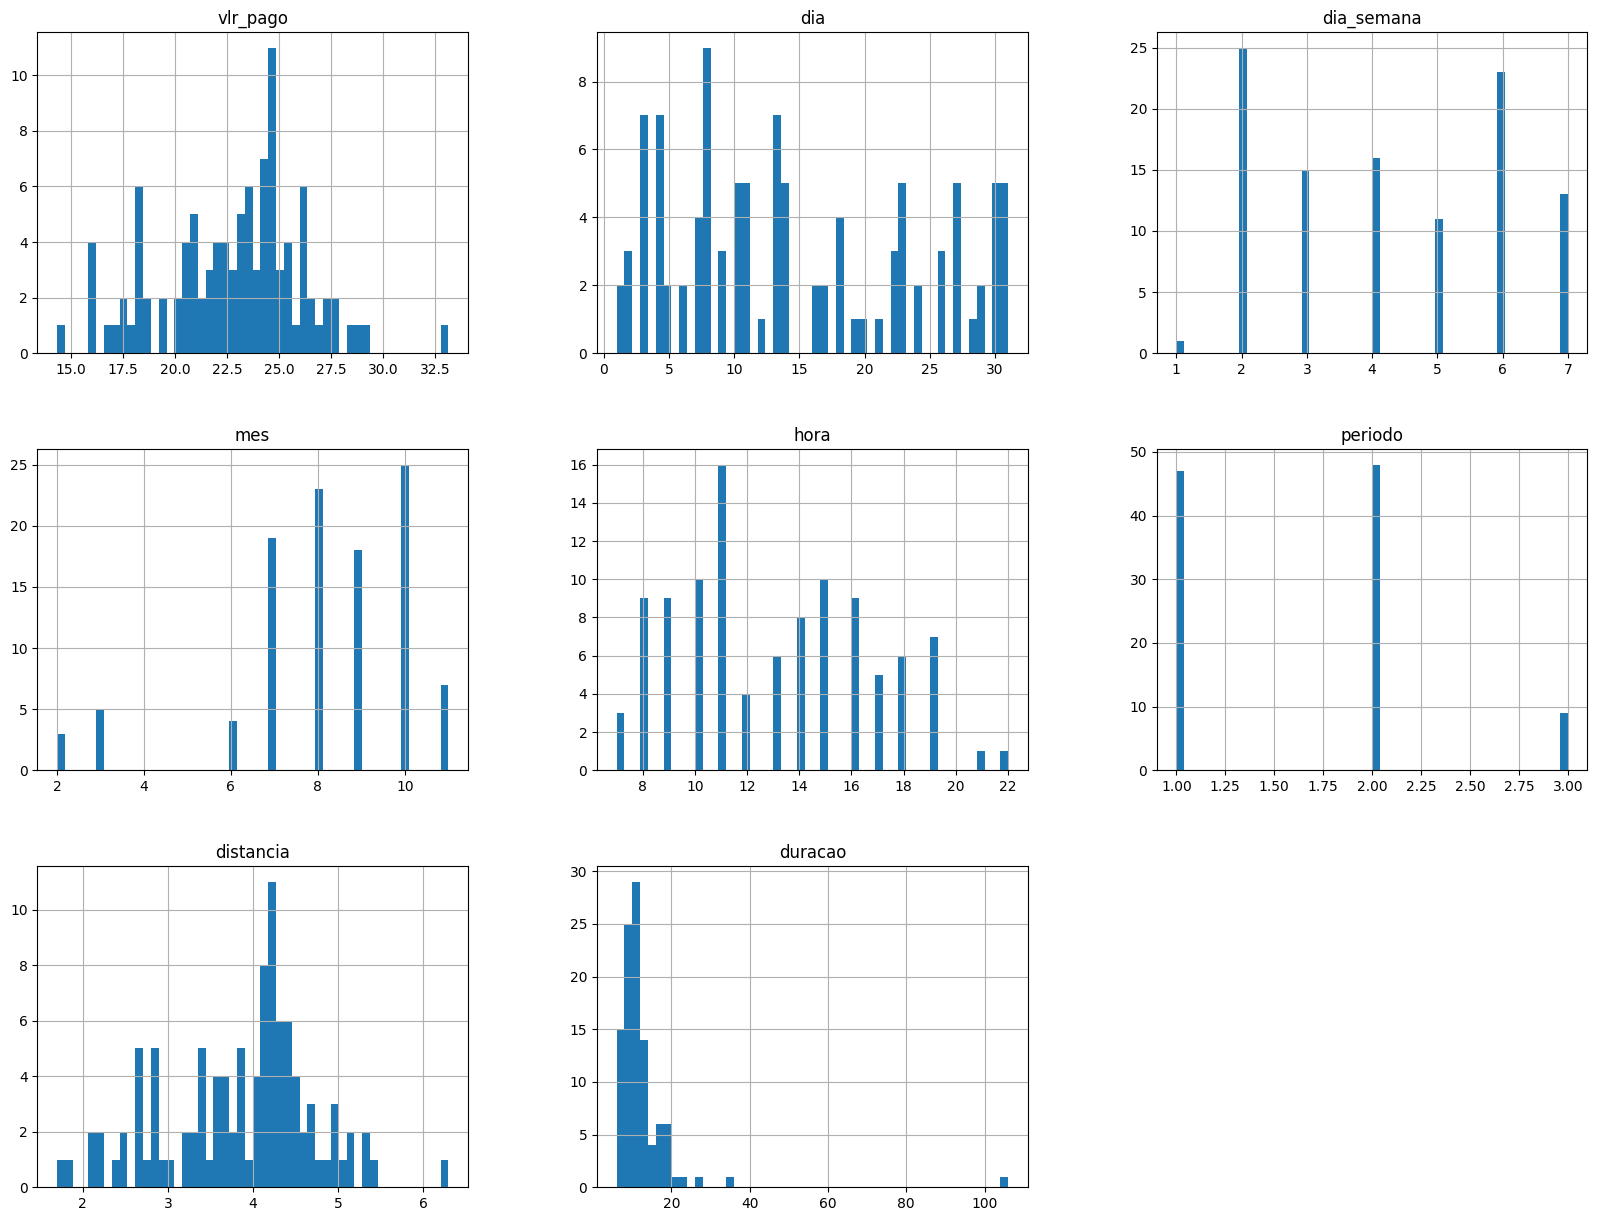

In [0]:
df.hist(bins=50, figsize=(20, 15));


In [0]:
df["mes"].value_counts()

mes
10    25
8     23
7     19
9     18
11     7
3      5
6      4
2      3
Name: count, dtype: int64

In [0]:
df[df["duracao"] > 50]

,vlr_pago,dia,dia_semana,mes,hora,periodo,distancia,duracao
7,27.0,10,6,10,19,3,4.918842,106


<Axes: >

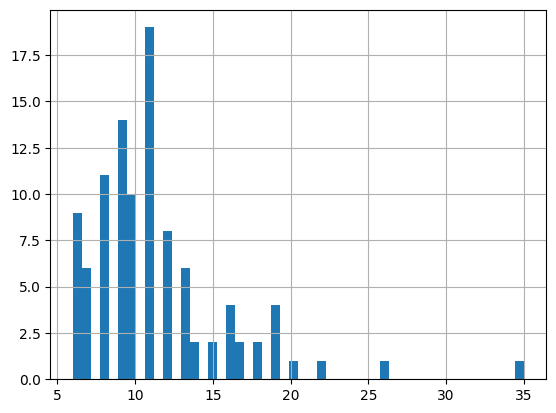

In [0]:
df[df["duracao"] < 50]["duracao"].hist(bins=50)


### Análise Bivariada

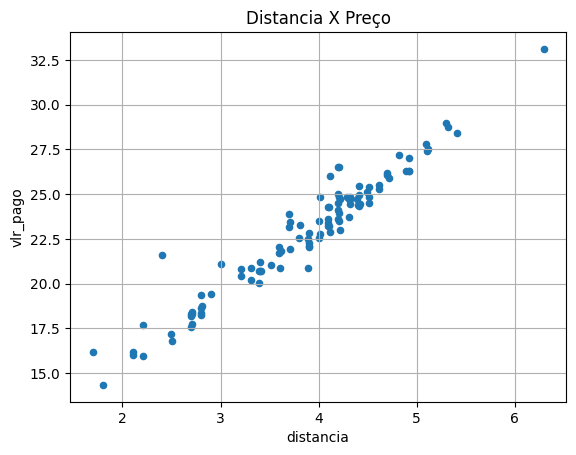

In [0]:
df[["distancia", "vlr_pago"]].plot(
    kind="scatter", x="distancia", y="vlr_pago", grid=True,
    title="Distancia X Preço"
);

In [0]:
df[["distancia", "vlr_pago"]].corr(method="pearson")

,distancia,vlr_pago
distancia,1.000000,0.966908
vlr_pago,0.966908,1.000000


In [0]:
df[["dia_semana", "vlr_pago"]].groupby("dia_semana").agg(
    qtd_corridas=("vlr_pago", "count"),
    pct_corridas=("vlr_pago", lambda x: x.count() / df.shape[0] * 100),
    pct_arrecadacao_dia=("vlr_pago", lambda x: x.sum() / df["vlr_pago"].sum() * 100),
    total_arrecadado=("vlr_pago", "sum"),
    media_arrecadado=("vlr_pago", "mean")
)

,qtd_corridas,pct_corridas,pct_arrecadacao_dia,total_arrecadado,media_arrecadado
dia_semana,,,,,
1,1,0.961538,0.674662,16.01,16.010000
2,25,24.038462,24.278984,576.15,23.046000
3,15,14.423077,14.462883,343.21,22.880667
4,16,15.384615,15.606564,370.35,23.146875
5,11,10.576923,10.149429,240.85,21.895455
6,23,22.115385,22.840323,542.01,23.565652
7,13,12.500000,11.987156,284.46,21.881538


In [0]:
df[["periodo", "vlr_pago"]].groupby("periodo").agg(
    qtd_corridas=("vlr_pago", "count"),
    pct_corridas=("vlr_pago", lambda x: x.count() / df.shape[0] * 100),
    pct_arrecadacao_dia=("vlr_pago", lambda x: x.sum() / df["vlr_pago"].sum() * 100),
    total_arrecadado=("vlr_pago", "sum"),
    media_arrecadado=("vlr_pago", "mean")
)

,qtd_corridas,pct_corridas,pct_arrecadacao_dia,total_arrecadado,media_arrecadado
periodo,,,,,
1,47,45.192308,45.707194,1084.65,23.077660
2,48,46.153846,44.638523,1059.29,22.068542
3,9,8.653846,9.654283,229.10,25.455556



### Análise multivariada

In [0]:
from seaborn import pairplot, heatmap

<Axes: >

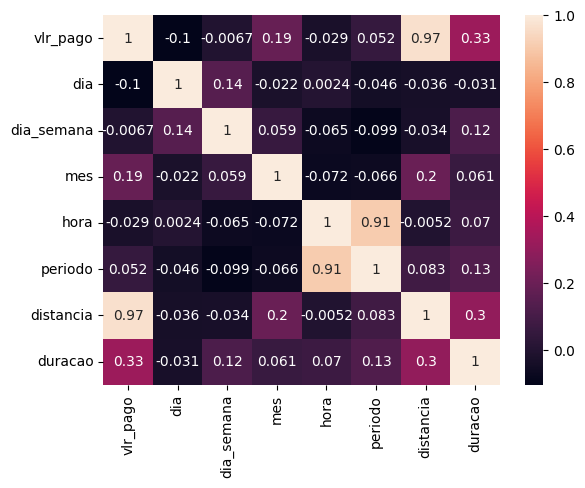

In [0]:
heatmap(df.corr(), annot=True)

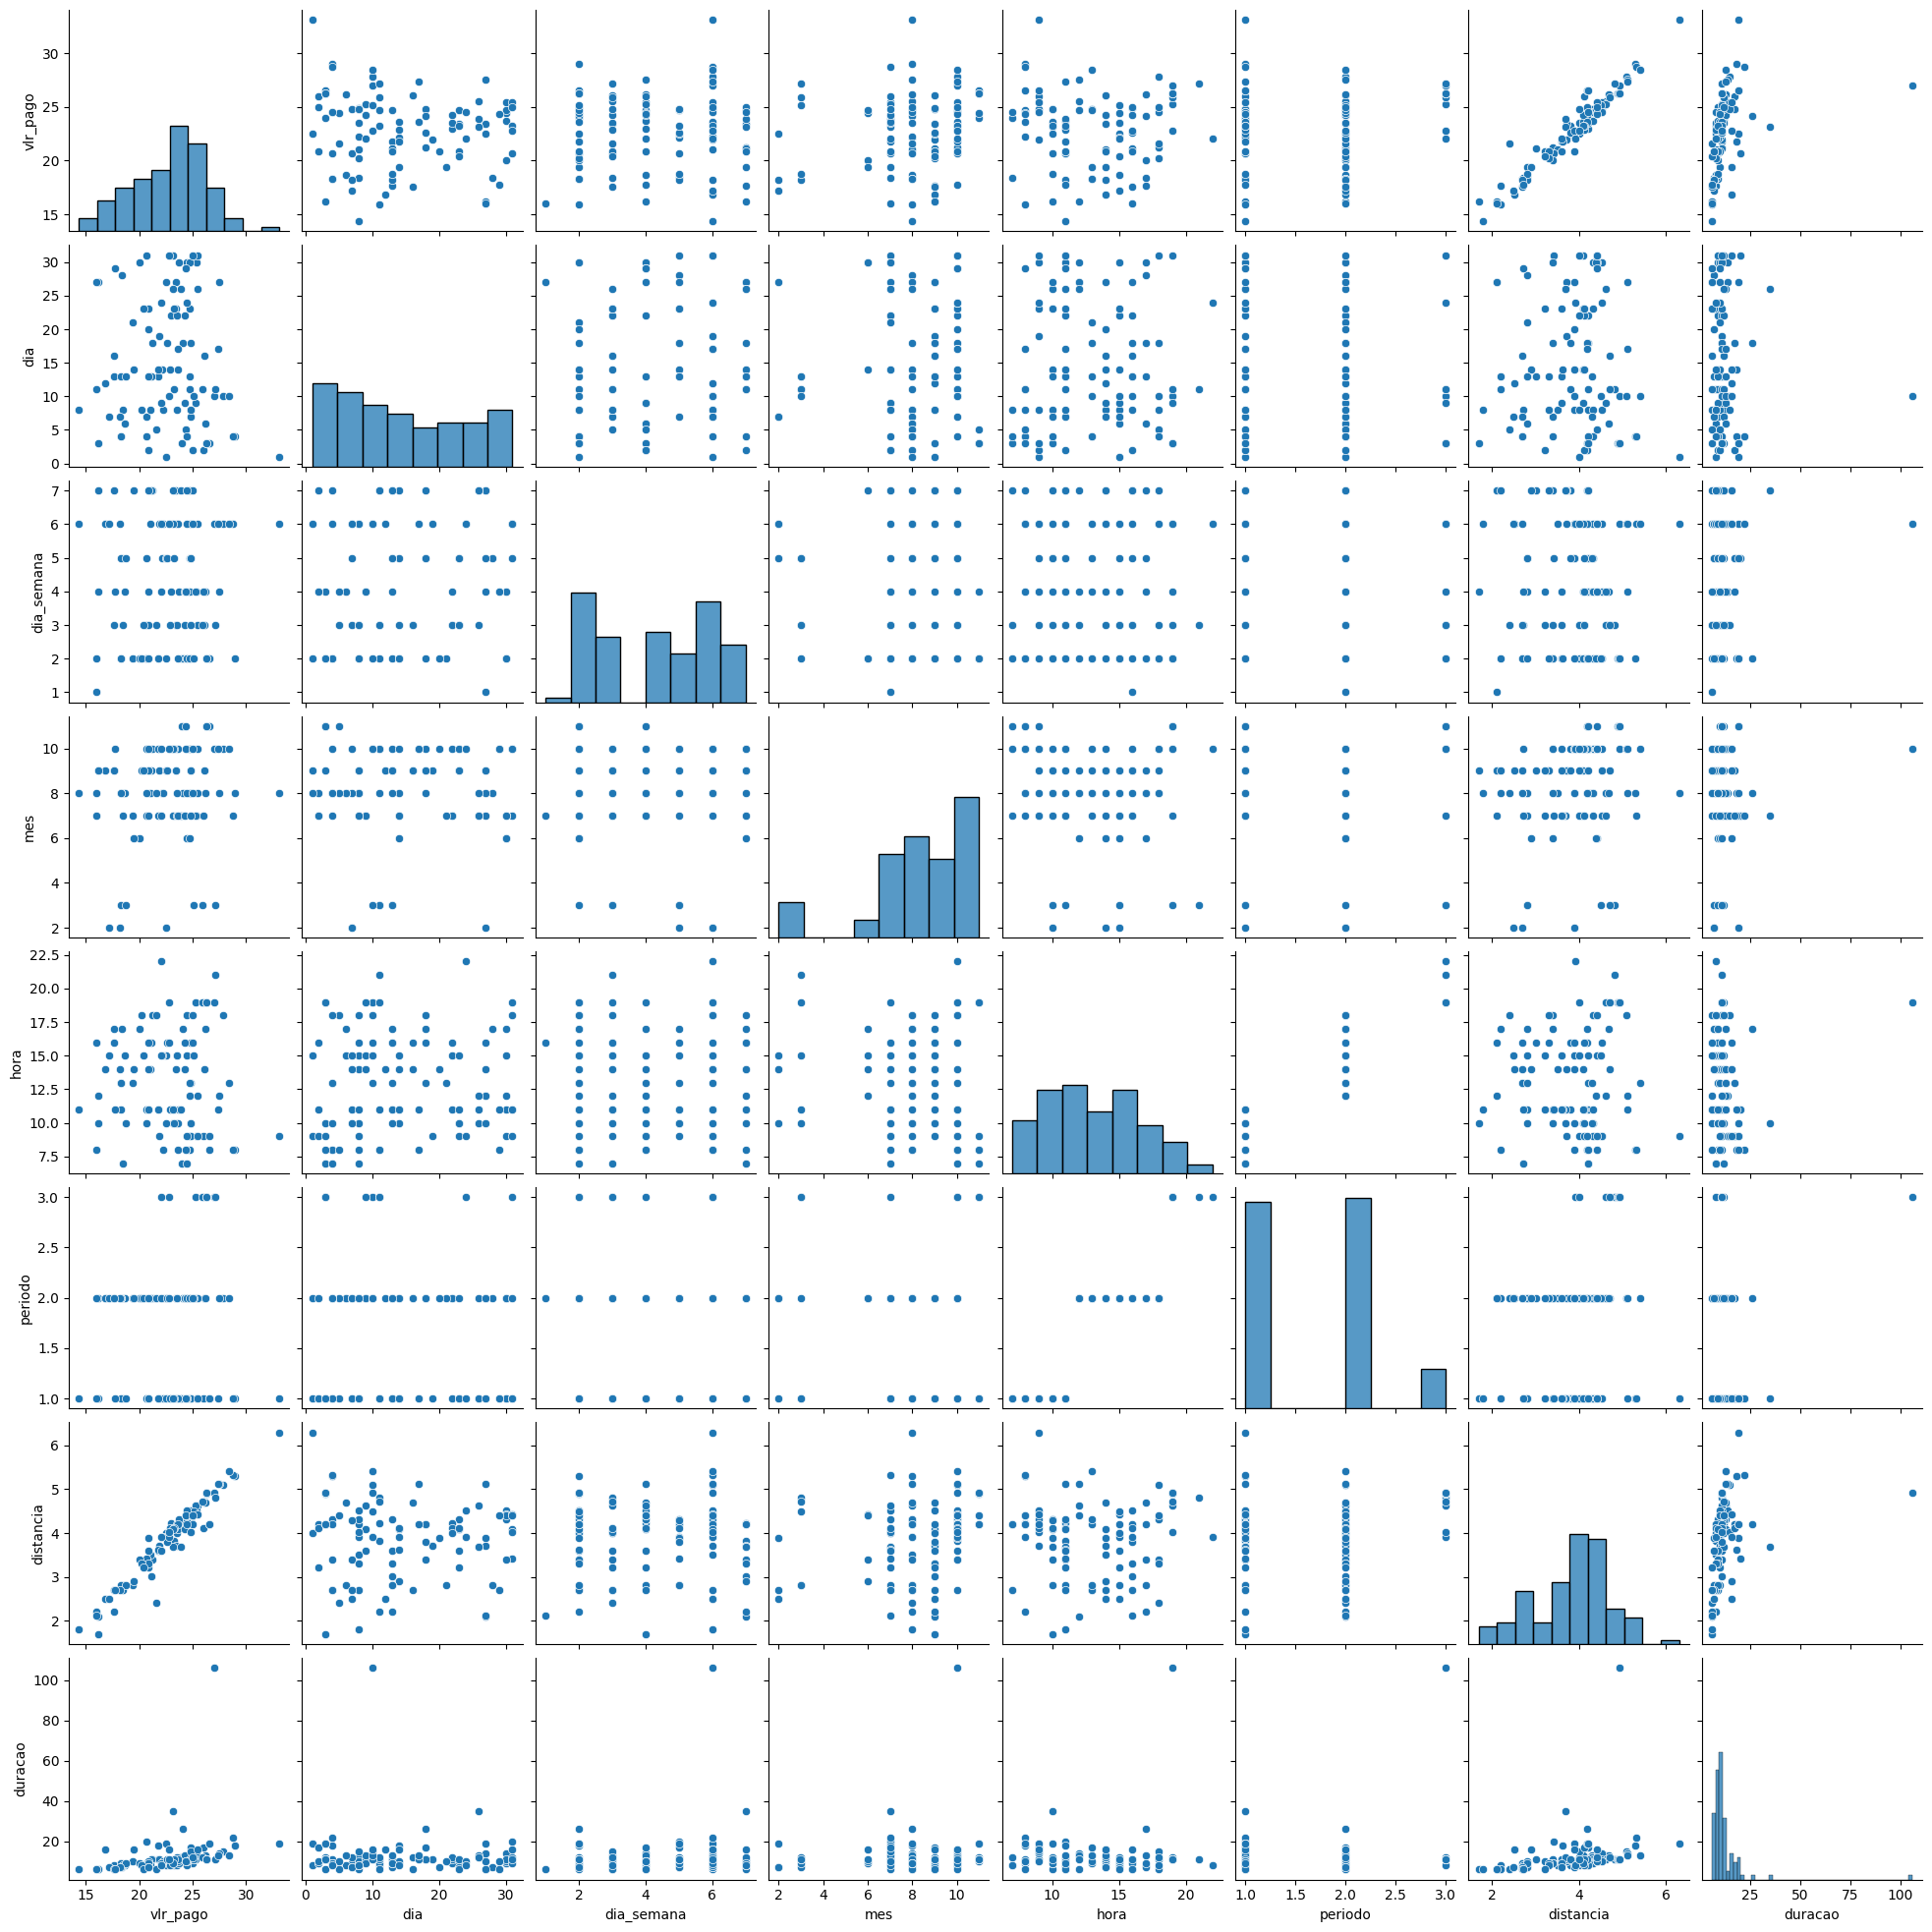

In [0]:
pairplot(df)